In [1]:
import joblib
import optuna
import copy
from optuna.samplers import RandomSampler, TPESampler
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice, plot_parallel_coordinate
import numpy as np
import pandas as pd
from tabpfn import TabPFNClassifier, TabPFNRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.linear_model import SGDClassifier, SGDRegressor, LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor 
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score
from fastparquet import write
from fastparquet import ParquetFile
from pathlib import Path
import datetime as dt
import time
import pytz
import json
import os

In [2]:
pst = pytz.timezone('America/Los_Angeles')
dt_str = dt.datetime.now(pst).strftime("%Y-%m-%d-%I_%M_%S_%p")
dt_str

'2026-08-26-04_53_54_PM'

In [3]:
oof_experiment_config = {
    "experiment": {
        "model": "xgboost",
        "type": "optuna",
        "num_trials": 2,
        "train_base_features": "baseline",
        "train_feature_groups": ["features", "target_encode", "freq_encode"],
        "description": "xgb + rand target + rand features + optuna tune",
    },

    "cv": {
        "strategy": "StratifiedKFold",
        "n_splits": 5,
        "shuffle": True,
        "random_state": 0
    },

    "features": {
        "class_sample_weight": False
    },

    "params": {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "enable_categorical": True,
        "early_stopping_rounds": 100,
        "device": "cuda",
        "n_jobs": -1,
        "verbosity": 0
    },
    
    "fit_params": {
    }
}
oof_experiment_config["experiment"]["id"] = f"{dt_str}_{oof_experiment_config["experiment"]["model"]}"
experiment_config = copy.deepcopy(oof_experiment_config)

In [4]:
def tune_params(trial):
    tree_method = trial.suggest_categorical("tree_method", ["hist", "approx"])
    booster = trial.suggest_categorical("booster", ["gbtree"])
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    if grow_policy == "lossguide":
        max_depth = 0
        max_leaves = trial.suggest_int('max_leaves', 8, 1024)
    else:
        max_depth = trial.suggest_int('max_depth', 2, 15)
        max_leaves = 0

    trial_params = {
        "n_estimators": trial.suggest_int('n_estimators', 100, 2000, step=50),
        'max_depth': max_depth,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.4, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.3, 1.0),
        "booster": booster,
        "lambda": trial.suggest_float("lambda", 1e-8, 50.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 50.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 20.0, log=True),
        "min_child_weight": trial.suggest_float('min_child_weight', 1, 30, log=True),
        "max_bin": trial.suggest_int('max_bin', 32, 256, step=10),
        "tree_method": tree_method,
        "grow_policy": grow_policy
    }

    if grow_policy == "lossguide":
        trial_params["max_leaves"] = max_leaves

    return trial_params 

In [5]:
sampler = RandomSampler()

In [6]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    data_path = "/kaggle/input/datasets/abhinavneelam/smartphone-addiction/data"
    output_path = "/kaggle/working/"
else:
    data_path = "../../data"
    output_path = "../../"

In [7]:
ss = pd.read_csv(f"{data_path}/raw/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [8]:
raw_train_df = pd.read_csv(f"{data_path}/raw/train.csv")
raw_train_id = raw_train_df["id"]
y = raw_train_df[target_column]

In [9]:
def make_model(config, optuna_params):
    name = config["experiment"]["model"]
    target = config["experiment"]["target"]
    params = config["params"]

    model_dict = {
        "adaboost": (AdaBoostClassifier, AdaBoostRegressor),
        "gradientboost": (GradientBoostingClassifier, GradientBoostingRegressor),
        "catboost": (CatBoostClassifier, CatBoostRegressor), # TODO - fix missing col issue in catboost
        "xgboost": (XGBClassifier, XGBRegressor),
        "lightgbm": (LGBMClassifier, LGBMRegressor),
        "randomforest": (RandomForestClassifier, RandomForestRegressor),
        "extratrees": (ExtraTreesClassifier, ExtraTreesRegressor),
        "hgbc": (HistGradientBoostingClassifier, HistGradientBoostingRegressor),
        "knn": (KNeighborsClassifier, KNeighborsRegressor),
        "sgd": (SGDClassifier, SGDRegressor),
        "linear": (LogisticRegression, LinearRegression),
        "decisiontree": (DecisionTreeClassifier, DecisionTreeRegressor),
        "mlp": (MLPClassifier, MLPRegressor),
        "tabpfn": (TabPFNClassifier, TabPFNRegressor),
    }

    target_index = target == "regression"
    model_class = model_dict[name][target_index]

    return model_class(**params, **optuna_params)

In [10]:
def oof_fit(config, model, X_train, y_train, X_valid, y_valid):
    name = config["experiment"]["model"]
    no_eval_models = ["adaboost", "gradientboost", "randomforest", "extratrees", "knn", "sgd", "linear", "decisiontree", "mlp", "tabpfn"]
    fit_params = config["fit_params"]
    
    if "features" in config and "class_sample_weight" in config["features"] and config["features"]["class_sample_weight"]:
        train_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    else:
        train_sample_weight = None

    if name in no_eval_models:
        model.fit(X_train, y_train, sample_weight=train_sample_weight)
    elif name == "hgbc":
        model.fit(X_train, y_train, X_val=X_valid, y_val=y_valid, sample_weight=train_sample_weight)
    elif name == "lightgbm":
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], sample_weight=train_sample_weight, **fit_params)
    else:
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], sample_weight=train_sample_weight, verbose=False)

In [11]:
def predict(config, model, X_feat):
    task = config["experiment"]["target"]
    if task == "classification":
        return model.predict_proba(X_feat)[:, 1]
    else:
        return model.predict(X_feat)

In [12]:
experiment_path = Path(output_path) / "experiments" / f"{dt_str}_optuna_{experiment_config["experiment"]["model"]}"
experiment_path.mkdir(parents=True, exist_ok=True)

In [13]:
def update_config(model, experiment_config):
    config = copy.deepcopy(experiment_config)
    params = config["params"]
    tree_param_keys = ["n_estimators", "max_iter"]

    best_iter = None
    if hasattr(model, "best_iteration_"):
        best_iter = model.best_iteration_
    elif hasattr(model, "best_iteration"):
        best_iter = model.best_iteration
    elif hasattr(model, "n_iter_"):
        n_iter_val = model.n_iter_
        
        if isinstance(n_iter_val, np.ndarray):
            if n_iter_val.size == 1:
                best_iter = n_iter_val.item()
            else:
                best_iter = int(n_iter_val.max())
        else:
            best_iter = int(n_iter_val)

    if best_iter is not None:
        for key in tree_param_keys:
            if key in params:
                params[key] = best_iter

    training_only_params = [
        "early_stopping_rounds",
        "early_stopping",
        "n_iter_no_change",
        "validation_fraction",
        "eval_set",
    ]

    for key in training_only_params:
        if key in params:
            del params[key]

    return config

In [14]:
cv_config = experiment_config["cv"]
exp_config = experiment_config["experiment"]

def objective(trial):
    X_base = ParquetFile(f"{data_path}/{exp_config["train_base_features"]}/train.parq").to_pandas()
    X_dfs = [X_base]

    target = trial.suggest_categorical(f"target", ["classification", "regression"])
    oof_experiment_config["experiment"]["target"] = target

    fg_trial = []
    
    for fg in exp_config["train_feature_groups"]:
        include_fg = trial.suggest_categorical(f"include_{fg}", [True, False])
        if include_fg:
            df = ParquetFile(f"{data_path}/{fg}/train.parq").to_pandas()
            fg_trial.append(fg)
            X_dfs.append(df)
    
    X = pd.concat(X_dfs, axis=1)
    kf = StratifiedKFold(n_splits=cv_config["n_splits"], random_state=cv_config["random_state"], shuffle=cv_config["shuffle"])
    
    train_index, valid_index = next(kf.split(X, y))
    valid_ids = raw_train_id.iloc[valid_index].reset_index(drop=True)

    X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
    y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

    local_dt_str = dt.datetime.now(pst).strftime("%Y-%m-%d-%I_%M_%S_%p")

    start_time = time.time()
    trial_params = tune_params(trial)
    model = make_model(oof_experiment_config, trial_params)

    oof_fit(
        oof_experiment_config,
        model,
        X_train,
        y_train,
        X_valid,
        y_valid
    )
    elapsed = time.time() - start_time
    
    y_pred = predict(oof_experiment_config, model, X_valid)
    y_pred_df = pd.concat([valid_ids, pd.Series(y_pred, name=target_column)], axis=1)
    valid_score = roc_auc_score(y_valid, y_pred)
    fold_scores = [round(valid_score, 5)]

    metrics = {
        "experiment": local_dt_str + f"_{experiment_config["experiment"]["model"]}",
        "model": f"{experiment_config["experiment"]["model"]}",
        "train_base_features": f"{experiment_config["experiment"]["train_base_features"]}",
        "train_feature_groups": fg_trial,
        "cv": {
            "strategy": f"{experiment_config["cv"]["strategy"]}",
            "n_splits": experiment_config["cv"]["n_splits"],
            "random_state": experiment_config["cv"]["random_state"],
            "fold_scores": fold_scores,
            "mean": round(sum(fold_scores) / len(fold_scores), 5),
            "std": 0.0
        },
        "primary_metric": {
            "name": "auc",
            "value": round(valid_score, 5)
        },
        "training": {
            "duration_seconds": round(elapsed, 2)
        }
    }

    tune_experiment_config = copy.deepcopy(oof_experiment_config)
    tune_experiment_config["params"] = oof_experiment_config["params"] | trial_params
    tune_experiment_config["experiment"]["train_feature_groups"] = fg_trial

    full_config = update_config(model, tune_experiment_config)

    model_experiment_path = experiment_path / f"{experiment_config["experiment"]["model"]}_trial_{trial.number}"
    model_experiment_path.mkdir(parents=True, exist_ok=True)

    with open(model_experiment_path / "oof_config.json", "w") as f:
        json.dump(tune_experiment_config, f, indent=4)

    with open(model_experiment_path / "full_config.json", "w") as f:
        json.dump(full_config, f, indent=4)

    with open(model_experiment_path / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    y_pred_df.to_csv(model_experiment_path / "oof.csv", index=False)
    joblib.dump(model, model_experiment_path / f"{experiment_config["experiment"]["model"]}.pkl")

    return valid_score

In [15]:
study = optuna.create_study(sampler=sampler, direction='maximize')
study.optimize(objective, n_trials=oof_experiment_config['experiment']['num_trials'])

[I 2026-08-26 23:53:56,159] A new study created in memory with name: no-name-a5fad2a5-ed9b-44d6-bdfc-00639289d97e
/tmp/ipykernel_45/1823986264.py:26: UserWarning: The distribution is specified by [32, 256] and step=10, but the range is not divisible by `step`. It will be replaced with [32, 252].
  "max_bin": trial.suggest_int('max_bin', 32, 256, step=10),
[I 2026-08-26 23:54:11,572] Trial 0 finished with value: 0.9480203438103199 and parameters: {'target': 'classification', 'include_features': True, 'include_target_encode': False, 'include_freq_encode': True, 'tree_method': 'hist', 'booster': 'gbtree', 'grow_policy': 'depthwise', 'max_depth': 11, 'n_estimators': 250, 'learning_rate': 0.039225362477156286, 'subsample': 0.8589670574183363, 'colsample_bytree': 0.3362315278518307, 'colsample_bynode': 0.6000624648202199, 'lambda': 2.4829337532361047, 'alpha': 0.00030765275884194333, 'gamma': 2.5927725258643994e-07, 'min_child_weight': 13.777473105460775, 'max_bin': 212}. Best is trial 0 wit

In [16]:
trial_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
trial_df.to_csv(experiment_path / "optuna_trials.csv", index=False)
trial_df

,number,value,params_alpha,params_booster,params_colsample_bynode,params_colsample_bytree,params_gamma,params_grow_policy,params_include_features,params_include_freq_encode,...,params_learning_rate,params_max_bin,params_max_depth,params_max_leaves,params_min_child_weight,params_n_estimators,params_subsample,params_target,params_tree_method,state
0,0,0.948020,0.000308,gbtree,0.600062,0.336232,2.592773e-07,depthwise,True,True,...,0.039225,212,11.0,NaN,13.777473,250,0.858967,classification,hist,COMPLETE
1,1,0.964509,4.043123,gbtree,0.466162,0.579802,1.048730e+00,lossguide,False,True,...,0.124728,102,NaN,583.0,1.696973,1950,0.411233,classification,hist,COMPLETE


In [17]:
study.best_trial.params

{'target': 'classification',
 'include_features': False,
 'include_target_encode': True,
 'include_freq_encode': True,
 'tree_method': 'hist',
 'booster': 'gbtree',
 'grow_policy': 'lossguide',
 'max_leaves': 583,
 'n_estimators': 1950,
 'learning_rate': 0.12472781780955208,
 'subsample': 0.4112325319412234,
 'colsample_bytree': 0.579801832785404,
 'colsample_bynode': 0.46616236774040215,
 'lambda': 0.0001522364118729626,
 'alpha': 4.043123377231192,
 'gamma': 1.0487301789592385,
 'min_child_weight': 1.6969725994351703,
 'max_bin': 102}

/tmp/ipykernel_45/3324289224.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

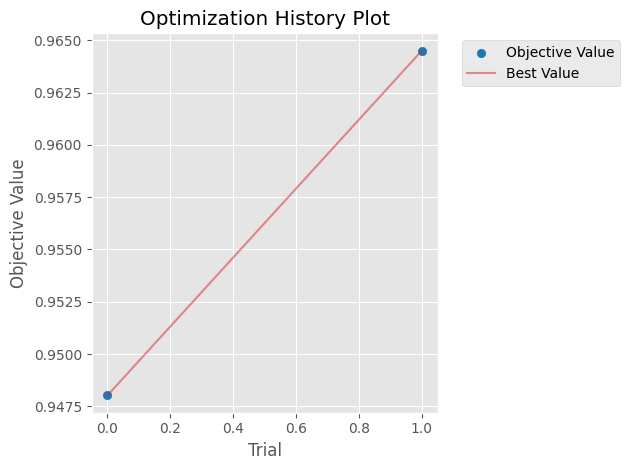

In [18]:
plot_optimization_history(study)

/tmp/ipykernel_45/3836449081.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

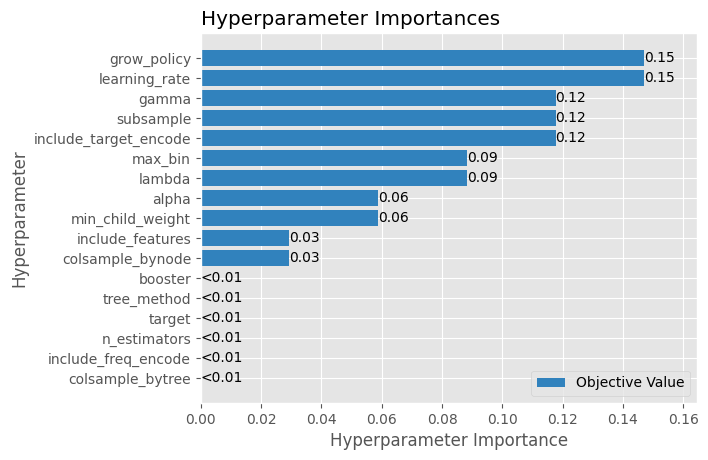

In [19]:
plot_param_importances(study)

/tmp/ipykernel_45/2457830863.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study)
/usr/local/lib/python3.12/dist-packages/optuna/visualization/matplotlib/_slice.py:153: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])


array([<Axes: xlabel='alpha', ylabel='Objective Value'>,
       <Axes: xlabel='booster'>, <Axes: xlabel='colsample_bynode'>,
       <Axes: xlabel='colsample_bytree'>, <Axes: xlabel='gamma'>,
       <Axes: xlabel='grow_policy'>, <Axes: xlabel='include_features'>,
       <Axes: xlabel='include_freq_encode'>,
       <Axes: xlabel='include_target_encode'>, <Axes: xlabel='lambda'>,
       <Axes: xlabel='learning_rate'>, <Axes: xlabel='max_bin'>,
       <Axes: xlabel='max_depth'>, <Axes: xlabel='max_leaves'>,
       <Axes: xlabel='min_child_weight'>, <Axes: xlabel='n_estimators'>,
       <Axes: xlabel='subsample'>, <Axes: xlabel='target'>,
       <Axes: xlabel='tree_method'>], dtype=object)

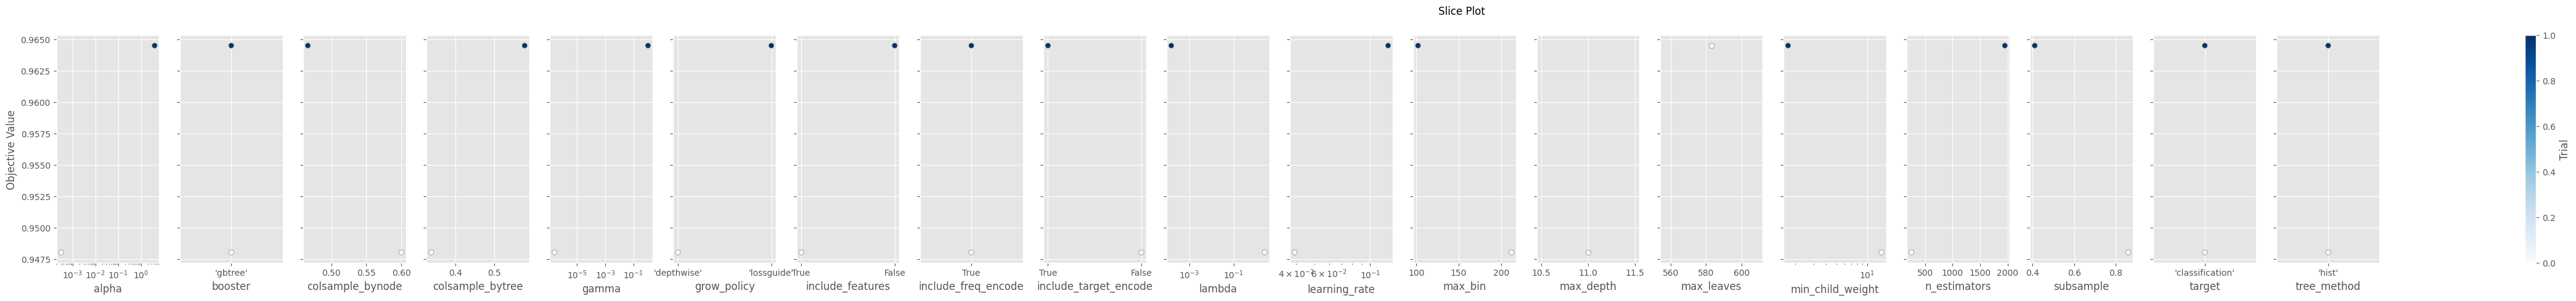

In [20]:
plot_slice(study)